In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Point
from shapely.geometry import Polygon

import matplotlib as mpl
from matplotlib.patches import Rectangle

import numpy as np
import matplotlib.patches as Patches
import xarray as xr 
import seaborn as sns 

This script uses the V5_misaligned_hotspots_0-50 dataset to identify the counties with the highest overall percentage of monitor/satellite hotspot misalignment, then clips the V6 PM grid data to bounding boxes around these counties. The values from these clipped grids are averaged over 2021-2023 and exported to "/data/beronio/epa_monitor/V6NA01.misaligned_counties_2021-2023_grid_cells.gpkg" The selected counties have 2+ monitors and have a monitor/hotspot alignment score of <= 15%


The second half of the script loads in the geopackage and recalculates hotspot and alignment percentages for the V6 grids in the most misaligned counties. Finally, it compares the V6 alignment metrics from those counties to their counterparts from the V5 data (V5_misaligned_hotspots_0-50)

In [4]:
# Local Path: 
alignment_pathv5 = '/Users/griffinberonio/Documents/Holloway_Group/Data/monitor_data/V5_misaligned_hotspots_0-50'
# alignment_pathv6 = '/data/beronio/epa_monitor/V6_select_counties_misaligned_hotspots_0-50'

alignmentv5 = pd.read_csv(alignment_pathv5)
# alignmentv6 = pd.read_csv(alignment_pathv6)

# print(f'V5: {alignmentv5.shape}, V6: {alignmentv6.shape}')

In [15]:

county_layer = alignmentv5[['COUNTYFP','GEOID', 'NAME', 'NAMELSAD',
       'STUSPS', 'STATE_NAME', 'total_monitors', 'pct','geometry']]

county_layerv6 = alignmentv6[['COUNTYFP','GEOID', 'NAME', 'NAMELSAD',
       'STUSPS', 'STATE_NAME', 'total_monitors', 'pct','geometry']]

county_shapefile = '/data/beronio/shapefiles/cb_2023_us_county_500k.shp'


states_to_include = [
    'AL','AZ','AR','CA','CO','CT','DE','FL','GA','ID','DC',
    'IL','IN','IA','KS','KY','LA','ME','MD','MA','MI','MN','MS',
    'MO','MT','NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK',
    'OR','PA','RI','SC','SD','TN','TX','UT','VT','VA','WA','WV',
    'WI','WY'
]

counties = gpd.read_file(county_shapefile)
print(counties.columns)
counties_conus = counties[counties['STUSPS'].isin(states_to_include)]
counties_conus = counties_conus.drop(["COUNTYNS", 'LSAD', 'ALAND', 'AWATER', 'GEOIDFQ'], axis=1)
counties_conus = counties_conus.to_crs(epsg=4326)

# Variable List for V5 Data (Includes 'GWRPM25_90th')

monitor_layer = alignmentv5[['total_monitors',
       'zones_in_hotspot', 'MICROSCALE', 'MIDDLE SCALE', 'NEIGHBORHOOD',
       'REGIONAL SCALE', 'URBAN SCALE', 'alignment_MICROSCALE',
       'alignment_MIDDLE SCALE', 'alignment_NEIGHBORHOOD',
       'alignment_URBAN SCALE', 'alignment_REGIONAL SCALE', 'pct',
       'GWRPM25_90th', 'monitor_geo']]


county_layer['geometry'] = gpd.GeoSeries.from_wkt(county_layer.loc[:,'geometry'])
county_plot = gpd.GeoDataFrame(county_layer,
                               geometry = county_layer.geometry,
                               crs = 5070)
county_plot = county_plot.to_crs(epsg=4326)

monitor_layer['monitor_geometry'] = gpd.GeoSeries.from_wkt(monitor_layer.loc[:,'monitor_geo'])

monitor_plot = gpd.GeoDataFrame(monitor_layer,
                                geometry = monitor_layer.monitor_geometry,
                                crs = 5070)
monitor_plot = monitor_plot.to_crs(epsg=4326)

monitor_layer6 = alignmentv6[['total_monitors',
       'zones_in_hotspot', 'MICROSCALE', 'MIDDLE SCALE', 'NEIGHBORHOOD',
       'REGIONAL SCALE', 'URBAN SCALE', 'alignment_MICROSCALE',
       'alignment_MIDDLE SCALE', 'alignment_NEIGHBORHOOD',
       'alignment_URBAN SCALE', 'alignment_REGIONAL SCALE', 'pct',
       'PM25_90th', 'monitor_geo']]

county_layerv6['geometry'] = gpd.GeoSeries.from_wkt(county_layerv6.loc[:,'geometry'])
county_plotv6 = gpd.GeoDataFrame(county_layerv6,
                               geometry = county_layerv6.geometry,
                               crs = 5070)
county_plotv6 = county_plotv6.to_crs(epsg=4326)

monitor_layer6['monitor_geometry'] = gpd.GeoSeries.from_wkt(monitor_layer6.loc[:,'monitor_geo'])

monitor_plotv6 = gpd.GeoDataFrame(monitor_layer6,
                                geometry = monitor_layer6.monitor_geometry,
                                crs = 5070)
monitor_plotv6 = monitor_plotv6.to_crs(epsg=4326)

# V5 uses monitor_plot, V6 uses monitor_plotv6

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'NAME',
       'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER',
       'geometry'],
      dtype='object')


/tmp/ipykernel_50643/2959445285.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  county_layer['geometry'] = gpd.GeoSeries.from_wkt(county_layer.loc[:,'geometry'])
/tmp/ipykernel_50643/2959445285.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monitor_layer['monitor_geometry'] = gpd.GeoSeries.from_wkt(monitor_layer.loc[:,'monitor_geo'])
/tmp/ipykernel_50643/2959445285.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

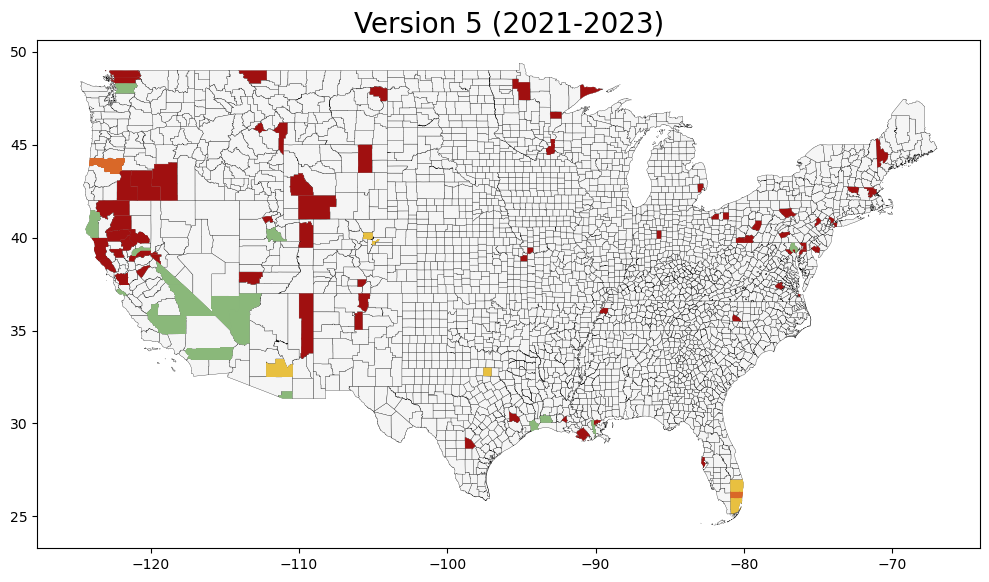

In [4]:
from matplotlib.patches import Patch
# sns.set_theme('whitegrid')
# sns.reset_defaults()

def color(row):

    val = row['pct']
    if pd.isna(val):   return '#EFEFEF'
    if val < 15:       return '#A01010'
    elif val < 30:     return '#D96828'
    elif val < 45:     return '#E8C040'
    elif val >= 45 :   return "#8AB87A"
    if pd.isna(val):   return '#EFEFEF'
    else:
        return 'black'

def plot_version(version):
    # V5 Data 
   
    if version == 5:
        fig, ax = plt.subplots(figsize=(10, 12))
        counties_conus.plot(ax=ax, facecolor='#f5f5f5', edgecolor='black', linewidth=0.2, zorder=1)
        county_plot['color'] = county_plot.apply(color, axis=1)

        county_plot.plot(ax=ax, color=county_plot['color'])
        hatch_subset = county_plot[county_plot['color'] == '#EFEFEF']
        
        if not hatch_subset.empty:
            hatch_subset.plot(ax=ax, facecolor='#EFEFEF', edgecolor='#bbbbbb', hatch='///', linewidth=0.2)

        plt.title('Version 5 (2021-2023)', fontsize = 20)
        plt.tight_layout()

    # V6 Data:
    elif version==6:
        fig, ax = plt.subplots(figsize=(10, 12))
        counties_conus.plot(ax=ax, facecolor='#f5f5f5', edgecolor='black', linewidth=0.2, zorder=1)
        county_plotv6['color'] = county_plotv6.apply(color, axis=1)

        county_plotv6.plot(ax=ax, color=county_plotv6['color'])

        hatch_subset = county_plotv6[county_plotv6['color'] == '#EFEFEF']
        if not hatch_subset.empty:
            hatch_subset.plot(ax=ax, facecolor='#EFEFEF', edgecolor='#bbbbbb', hatch='///', linewidth=0.2)
        
        plt.title('Version 6 (2021-2023)', fontsize = 20)
        plt.tight_layout()

    else:
        fig, axes = plt.subplots(2,1, figsize=(10,12))
        counties_conus.plot(ax=axes[0], facecolor='#f5f5f5', edgecolor='black', linewidth=0.2, zorder=1, label='Version 5')
        counties_conus.plot(ax=axes[1], facecolor='#f5f5f5', edgecolor='black', linewidth=0.2, zorder=1, label='Version 6')
        county_plot['color'] = county_plot.apply(color, axis=1)
        county_plotv6['color'] = county_plotv6.apply(color, axis=1)
        county_plot.plot(ax=axes[0], color=county_plot['color'])
        county_plotv6.plot(ax=axes[1], color= county_plotv6['color'])
        hatch_subsetv5 = county_plot[county_plot['color'] == '#EFEFEF']
        hatch_subsetv6 = county_plotv6[county_plotv6['color'] == '#EFEFEF']
        if not (hatch_subsetv5.empty or hatch_subsetv6.empty):
            hatch_subsetv5.plot(ax=axes[0], facecolor='#EFEFEF', edgecolor='#bbbbbb', hatch='///', linewidth=0.2)
            hatch_subsetv6.plot(ax=axes[1], facecolor='#EFEFEF', edgecolor='#bbbbbb', hatch='///', linewidth=0.2)

        axes[0].set_title('Version 5', fontsize= 20)
        axes[1].set_title('Version 6', fontsize = 20)
        plt.tight_layout()
    
    plt.show()


plot_version(5)

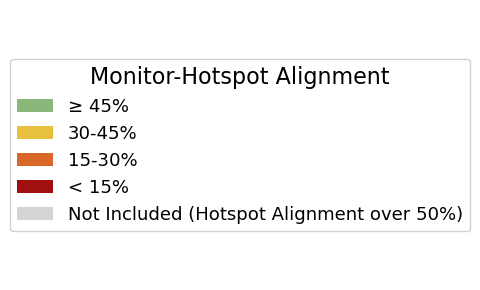

In [5]:


handles = [
    Patch(facecolor='#8AB87A', label='≥ 45%'),
    Patch(facecolor='#E8C040', label='30-45%'),
    Patch(facecolor='#D96828', label='15-30%'),
    Patch(facecolor='#A01010', label='< 15%'),
    Patch(facecolor='#D4D4D4', label='Not Included (Hotspot Alignment over 50%)')
    # Patch(facecolor='#D4D4D4', label='No monitor, hotspot present'),
    # Patch(facecolor='#EFEFEF', hatch='///', edgecolor='#bbbbbb', label='No monitor, no hotspot'),
]

fig, ax = plt.subplots(figsize=(5, 3))
# ax.set_title('Hot Spot - EPA Monitor Alignment (50% or less)')
ax.title.set_fontsize(20)
ax.legend(handles=handles, title='Monitor-Hotspot Alignment', title_fontsize=16,
          loc='center', fontsize=13, framealpha=0.9)
ax.set_axis_off()

plt.tight_layout()
# plt.savefig('alignment_map_50_less_combined_2021_2023.png', dpi=600, bbox_inches='tight')



/home/beronio/miniconda3/envs/beronio_envir/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


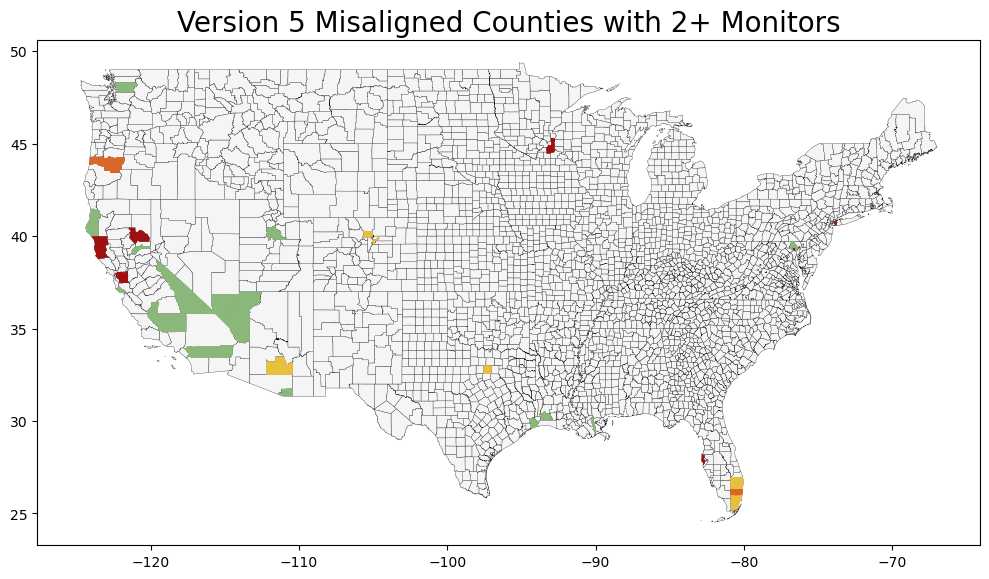

In [5]:
# Filtering hotspot counties with 2+ monitors: 
def hotspots_2monitors(version):

    if version == 5:

        filtered_counties = county_plot[county_plot.loc[:,'total_monitors'] >= 2]

        filtered_counties['color'] = filtered_counties.apply(color, axis=1)

        fig, ax = plt.subplots(figsize=(10, 12))

        counties_conus.plot(ax=ax, facecolor='#f5f5f5', edgecolor='black', linewidth=0.2, zorder=1)
        filtered_counties.plot(ax=ax, color=filtered_counties['color'])
        hatch_subset = filtered_counties[filtered_counties['color'] == '#EFEFEF']
        if not hatch_subset.empty:
            hatch_subset.plot(ax=ax, facecolor='#EFEFEF', edgecolor='#bbbbbb', hatch='///', linewidth=0.2)

        ax.set_title('Version 5 Misaligned Counties with 2+ Monitors', fontsize=20)
        plt.tight_layout()

    elif version == 6:
        filtered_counties = county_plotv6[county_plotv6.loc[:,'total_monitors'] >= 2]

        filtered_counties['color'] = filtered_counties.apply(color, axis=1)

        fig, ax = plt.subplots(figsize=(10, 12))

        counties_conus.plot(ax=ax, facecolor='#f5f5f5', edgecolor='black', linewidth=0.2, zorder=1)
        filtered_counties.plot(ax=ax, color=filtered_counties['color'])
        hatch_subset = filtered_counties[filtered_counties['color'] == '#EFEFEF']
        if not hatch_subset.empty:
            hatch_subset.plot(ax=ax, facecolor='#EFEFEF', edgecolor='#bbbbbb', hatch='///', linewidth=0.2)

        ax.set_title('Version 6 Misaligned Counties with 2+ Monitors', fontsize=20)
        plt.tight_layout()
    plt.show()



hotspots_2monitors(5)


In [ ]:
filtered_counties = county_plot[county_plot.loc[:,'total_monitors'] >= 2]

most_misaligned = filtered_counties[filtered_counties['pct'] <= 15]

test_coords = most_misaligned.loc[:1].get_coordinates()
test_coords
test_county = most_misaligned.iloc[:1]

# DF that includes only counties with 2+ monitors and alignment < 15%:
# most_misaligned.head()

# DF that includes all counties with v5 CDVE alignment < 50%:
cols_to_keep = ['COUNTYFP','GEOID','NAME','STUSPS','STATE_NAME','total_monitors','pct',
                'geometry','color']
county_plot['color'] = county_plot.apply(color, axis=1)
county_plotv6['color'] = county_plotv6.apply(color, axis=1)

fulldf_under50 = county_plot[cols_to_keep]

fulldf_under50['NAME'].unique()



92

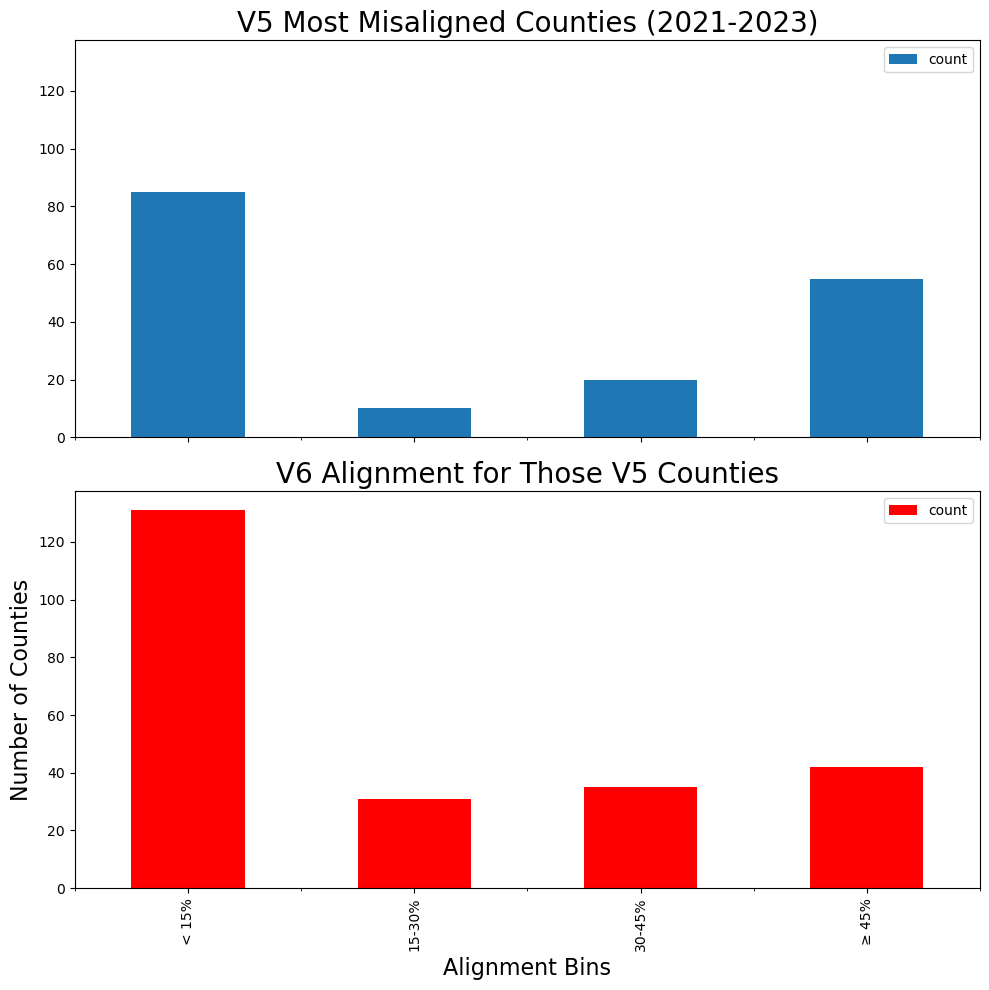

In [13]:
# Graphing the amounts/ levels of misaligned counties in v5 and v6: 
binmap = {"#A01010": ("< 15%",1),
          "#D96828": ("15-30%",2),
          "#E8C040": ("30-45%",3),
          "#8AB87A": ("≥ 45%",4),
          "#EFEFEF": ("Not Included (Hotspot Alignment over 50%)",5)}

v5bins = pd.DataFrame(county_plot['color'].value_counts().reset_index())
v5bins['bin'] = v5bins['color'].map(binmap)
v5bins['num'] = v5bins['bin'].apply(lambda x: x[1])
v5bins['bin'] = v5bins['bin'].apply(lambda x: x[0])

v6bins = pd.DataFrame(county_plotv6['color'].value_counts().reset_index())
v6bins['bin'] = v6bins['color'].map(binmap)
v6bins['num'] = v6bins['bin'].apply(lambda x: x[1])
v6bins['bin'] = v6bins['bin'].apply(lambda x: x[0])

v5bins = v5bins.sort_values('num').reset_index(drop=True)
v6bins = v6bins.sort_values('num').reset_index(drop=True)


fig, axs = plt.subplots(2,1,figsize=(10, 10), sharey=True, sharex=True)
v5bins.plot.bar(ax = axs[0], x='bin', y='count', sharey=axs[1])
v6bins.plot.bar(ax=axs[1], x='bin', y='count', color='red')
axs[0].set_title('V5 Most Misaligned Counties (2021-2023)', fontsize=20)
axs[1].set_title('V6 Alignment for Those V5 Counties', fontsize=20)
plt.xlabel('Alignment Bins', fontsize=16)
plt.ylabel('Number of Counties', fontsize=16)

plt.tight_layout()
plt.show()

# v5bins

In [93]:
# Most misaligned counties with 2 + monitors between versions:

v5names = county_plot[(county_plot['total_monitors'] >= 2) & (county_plot['pct'] < 15)].sort_values('pct')['NAME'].drop_duplicates().tolist()
v6names = county_plotv6[(county_plotv6['total_monitors'] >= 2) & (county_plotv6['pct'] < 15)].sort_values('pct')['NAME'].drop_duplicates().tolist()
namedict = {'V5': v5names, 'V6': v6names}

differentnames = list(set(v5names).symmetric_difference(set(v6names)))

v5lowdf = county_plot[county_plot['NAME'].isin(v5names)]
v6lowdf = county_plotv6[county_plotv6['NAME'].isin(v6names)]
v6lowdf['VERSION'] = 'V6'
v5lowdf['VERSION'] = 'V5'
v6lowdf = v6lowdf[['STATE_NAME','STUSPS','NAME','VERSION']].drop_duplicates()
v5lowdf = v5lowdf[['STATE_NAME','STUSPS','NAME','VERSION']].drop_duplicates()

lowdf = pd.concat([v5lowdf,v6lowdf])
csvfilepath = '/data/beronio/epa_monitor/most_misaligned_counties_per_version'

lowdf.to_csv(csvfilepath)

/home/beronio/miniconda3/envs/beronio_envir/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/beronio/miniconda3/envs/beronio_envir/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Clipping V6 Grid Data by V5 misaligned county bounding boxes: 

In [17]:
# Total counties from V5 used to create bounding boxes for V6 grid cells:
print(f'Number of Unique V5 Counties: {len(fulldf_under50['NAME'].unique())}')

Number of Unique V5 Counties: 92


In [40]:
# Defining Bounding boxes around the most misaligned counties: 

def bounding_boxes(countydf):

    boxdf = None
    box = {}  
    countynames = list(countydf['NAME'].unique())
    counter = 0
    for county in countynames:
        counter +=1
        # tempcounty = most_misaligned[most_misaligned['NAME']==county]
        tempcounty = countydf[countydf.loc[:,'NAME'] == county]

        bounds = tempcounty.bounds
        box['county'] = county
        box['GEOID'] = tempcounty['GEOID']
        box['minx'] = bounds['minx']
        box['miny'] = bounds['miny'] 
        box['maxx'] = bounds['maxx']
        box['maxy'] = bounds['maxy']
        box['geometry'] = tempcounty['geometry']

        if boxdf is None:
            boxdf = pd.DataFrame(box).reset_index()
        else:
            temp = pd.DataFrame(box).reset_index()
            boxdf = pd.concat([boxdf,temp],ignore_index=True)
        
        finalboxdf = boxdf.drop_duplicates('county')
    return finalboxdf
        
boxes = bounding_boxes(most_misaligned)
boxesfull = bounding_boxes(fulldf_under50)

boxesfull.shape

(92, 8)

Producing Clipped Grid Cells V5 & V6

In [18]:
# V6 Data Paths:
import cartopy.crs as ccrs

v6unc2023 = '/data/beronio/WashU_V6_GL/V6NA01.CNNPM25.AbsoluteUncertainty.202301-202312.nc'
v6data2023 = '/data/beronio/WashU_V6_GL/V6NA01.CNNPM25.PM25.202301-202312.nc'
v6unc2022 = '/data/beronio/WashU_V6_GL/V6NA01.CNNPM25.AbsoluteUncertainty.202201-202212.nc'
v6data2022 = '/data/beronio/WashU_V6_GL/V6NA01.CNNPM25.PM25.202201-202212.nc'
v6unc2021 = '/data/beronio/WashU_V6_GL/V6NA01.CNNPM25.AbsoluteUncertainty.202101-202112.nc'
v6data2021 = '/data/beronio/WashU_V6_GL/V6NA01.CNNPM25.PM25.202101-202112.nc'

v5data2021 = '/data/acker/WashU_V5_GL/V5GL0502.HybridPM25.Global.202101-202112.nc'
v5unc2021 = '/data/acker/WashU_GL_unc/V5GL0502.HybridPM25E.Global.202101-202112.nc'
v5data2022 = '/data/acker/WashU_V5_GL/V5GL0502.HybridPM25.Global.202201-202212.nc'
v5unc2022 = '/data/acker/WashU_GL_unc/V5GL0502.HybridPM25E.Global.202201-202212.nc'
v5data2023 = '/data/acker/WashU_V5_GL/V5GL0502.HybridPM25.Global.202301-202312.nc'
v5unc2023 = '/data/acker/WashU_GL_unc/V5GL0502.HybridPM25E.Global.202301-202312.nc'

# Chunked test file:
# dsdata2023 = xr.open_dataset(v6data2023, chunks={"x": 500, "y": 500})
# dsunc2023 = xr.open_dataset(v6unc2023, chunks={"x":500, "y": 500})


In [72]:


def clip_v6(satfile, uncfile, boxdf, buffer=0, version=6):

    target_counties = list(boxdf['county'].unique())
    county_bounds = None

    for county in target_counties:
        print(f'Starting Process for: {county} County...')

        # Specifying bounding box for x county:
        tempslice = boxdf[boxdf['county']==county]
        minx = tempslice['minx'].values[0]
        maxx = tempslice['maxx'].values[0]
        miny = tempslice['miny'].values[0]
        maxy = tempslice['maxy'].values[0]
        geoid = tempslice['GEOID'].values[0]
        
        sat_data = xr.open_dataset(satfile, engine='netcdf4').sel(
        lon=slice(minx, maxx + buffer),
        lat=slice(miny, maxy - buffer)).to_dataframe()

        unc_data = xr.open_dataset(uncfile, engine='netcdf4').sel(
        lon=slice(minx, maxx + buffer),
        lat=slice(miny, maxy - buffer)).to_dataframe()

        # print(sat_data.head())

        if version == 6:
            unc_data = unc_data.rename(columns={'PM25': 'GWRPM25SIGMA'})
            
            merged = pd.merge(sat_data, unc_data, left_index=True, right_index=True, how='inner')
            merged.reset_index(inplace=True)
            merged['percent'] = (merged['GWRPM25SIGMA'] / merged['PM25']) * 100
            to_use = merged[merged['percent'] < 90][['lat', 'lon', 'PM25']]

        elif version == 5:
            merged = pd.merge(sat_data, unc_data, left_index=True, right_index=True, how='left').reset_index()
            merged['percent'] = (merged['GWRPM25SIGMA'] / merged['GWRPM25']) * 100
            # print(merged.head())
            to_use = merged[merged['percent'] < 90][['lat', 'lon', 'GWRPM25']]
    

            
        to_use['county'] = county
        to_use['GEOID'] = geoid
        
        if county_bounds is None:
            county_bounds = to_use
        else:
            county_bounds = pd.concat([county_bounds, to_use])
            
    return county_bounds



In [76]:
import os

def to_polygons_chunked(df, output_path, version=6, chunk_size=10000):
    df = df.sort_values(['lat', 'lon']).reset_index(drop=True)
    lat_unique = np.sort(df['lat'].unique())
    lon_unique = np.sort(df['lon'].unique())
    # geoid = np.sort(df['GEOID'].unique())
    if version == 6:
        pm_lookup = {(row.lat, row.lon): row.PM25 for row in df.itertuples(index=False)}
    elif version == 5:
        pm_lookup = {(row.lat, row.lon): row.GWRPM25 for row in df.itertuples(index=False)}
    # geoid_lookup = {(row.lat, row.lon): row.GEOID for row in df.itertuples(index=False)}

    if os.path.exists(output_path):
        os.remove(output_path)

    geoms, values, lats, lons, geoids = [], [], [], [], []
    count = 0
    first_write = True

    for i in range(len(lat_unique) - 1):
        for j in range(len(lon_unique) - 1):
            lat = lat_unique[i]
            lon = lon_unique[j]
            val = pm_lookup.get((lat, lon), np.nan)
            if not np.isnan(val):
                corners = [
                    (lon, lat),
                    (lon_unique[j+1], lat),
                    (lon_unique[j+1], lat_unique[i+1]),
                    (lon, lat_unique[i+1])
                ]
                geoms.append(Polygon(corners))
                values.append(val)
                lats.append(lat)
                lons.append(lon)
                # geoids.append(geoid_lookup.get((lat, lon), None))
                count += 1

                if count % chunk_size == 0:
                    if version == 6:
                        gdf_chunk = gpd.GeoDataFrame({
                            'PM25': values,
                            'lat': lats,
                            'lon': lons,
                            'geometry': geoms,
                            # 'GEOID': geoids
                            
                        }, crs="EPSG:4326").to_crs("EPSG:4269")
                    elif version == 5:
                        gdf_chunk = gpd.GeoDataFrame({
                            'GWRPM25': values,
                            'lat': lats,
                            'lon': lons,
                            'geometry': geoms,
                            # 'GEOID': geoids
                            
                        }, crs="EPSG:4326").to_crs("EPSG:4269")

                    # gdf_chunk.to_file(output_path, driver='shp', mode='w' if first_write else 'a')
                    gdf_chunk.to_file(output_path, mode='w' if first_write else 'a')
                    first_write = False
                    geoms, values, lats, lons = [], [], [], []

    # Final 
    if geoms:
        if version == 6:
            gdf_chunk = gpd.GeoDataFrame({
                'PM25': values,
                'lat': lats,
                'lon': lons,
                'geometry': geoms,
                # 'GEOID': geoids
            }, crs="EPSG:4326").to_crs("EPSG:4269")
            
        elif version == 5:
            gdf_chunk = gpd.GeoDataFrame({
                'GWRPM25': values,
                'lat': lats,
                'lon': lons,
                'geometry': geoms,
                # 'GEOID': geoids
            }, crs="EPSG:4326").to_crs("EPSG:4269")
            
        # gdf_chunk = gpd.GeoDataFrame({
        #     'PM25': values,
        #     'lat': lats,
        #     'lon': lons,
        #     'geometry': geoms,
        #     # 'GEOID': geoids
        # }, crs="EPSG:4326").to_crs("EPSG:4269")
        
        # gdf_chunk.to_file(output_path, driver='GPKG', mode='w' if first_write else 'a')
        gdf_chunk.to_file(output_path, mode='w' if first_write else 'a') # For making shapefiles instead of geopackages


In [82]:
# Processing each year for data from (2+ monitors, < 15%): 

# clipped2021 = clip_v6(v6data2021,v6unc2021,boxes,0.1)
# clipped2022 = clip_v6(v6data2022,v6unc2022,boxes,0.1)
# clipped2023 = clip_v6(v6data2023,v6unc2023,boxes,0.1)

# Processing each year of V6 data from all counties <50% alignment V5:

clipped2021 = clip_v6(v6data2021,v6unc2021,boxesfull,0.1)
clipped2022 = clip_v6(v6data2022,v6unc2022,boxesfull,0.1)
clipped2023 = clip_v6(v6data2023,v6unc2023,boxesfull,0.1)

threeyears = pd.concat([clipped2021,clipped2022,clipped2023])

# Processing each year of the V5 data from all counties <50% alignment V5:
clip2021_v5 = clip_v6(v5data2021,v5unc2021,boxesfull,0.1, version = 5)
clip2022_v5 = clip_v6(v5data2022,v5unc2022,boxesfull,0.1, version = 5)
clip2023_v5 = clip_v6(v5data2023,v5unc2023,boxesfull,0.1, version = 5)

threeyears = pd.concat([clip2021_v5,clip2022_v5,clip2023_v5])

# Average over the three years:
    #Version 6:
# mean_df = threeyears.groupby(['lat', 'lon','GEOID','county'])['PM25'].mean().reset_index()
    #Version 5:
mean_df_v5 = threeyears.groupby(['lat', 'lon','GEOID','county'])['GWRPM25'].mean().reset_index()



Starting Process for: Norfolk County...
Starting Process for: Pinellas County...
Starting Process for: Howard County...
Starting Process for: Klamath County...
Starting Process for: Uintah County...
Starting Process for: Glacier County...
Starting Process for: Davis County...
Starting Process for: Fayette County...
Starting Process for: Johnson County...
Starting Process for: Whatcom County...
Starting Process for: Indiana County...
Starting Process for: Carlton County...
Starting Process for: Carson City County...
Starting Process for: Portage County...
Starting Process for: Cumberland County...
Starting Process for: Orleans County...
Starting Process for: Kent County...
Starting Process for: Campbell County...
Starting Process for: Middlesex County...
Starting Process for: Cook County...
Starting Process for: Bergen County...
Starting Process for: Richland County...
Starting Process for: Taos County...
Starting Process for: Colusa County...
Starting Process for: Plumas County...
Star

In [83]:
print('Converting to polygons in chunks...')
grid_most_path = '/data/beronio/epa_monitor/V6NA01.misaligned_counties_2021-2023_grid_cells.gpkg'
grid_full_path = '/data/beronio/epa_monitor/V6NA01.counties_under_50_2021-2023_grid_cells.gpkg'
grid_v5_path = '/data/beronio/epa_monitor/V5NA01.counties_under_50_2021-2023_grid_cells.gpkg'

# For most misaligned counties: 
# to_polygons_chunked(mean_df, grid_path_most, chunk_size=10000)

# For all counties under 50%:
# v6grids = to_polygons_chunked(mean_df,grid_path_full,chunk_size=10000)
v5grids = to_polygons_chunked(mean_df_v5,grid_v5_path, version=5, chunk_size=10000)

Converting to polygons in chunks...


Reading in Geopackage and recalculating hotspots and alignment for V6 data:

In [84]:

v6grids = gpd.read_file(grid_full_path)
v6grids.shape

(783702, 4)

In [ ]:
# Recalculating hotspot locations: 

    # EPA monitors from 2021-2023: 

gdf_epa = pd.read_csv('/data/wells/epa_monitor/pm25_monitor_sites_merged_2021_2022_2023_WGS84.csv', encoding='latin1')

# Columns to keep
columns_to_keep = ['AQS_Site_ID', 'Latitude', 'Longitude', 'Measurement_Scale']

# Keep only relevant columns
gdf_epa_clean = gdf_epa[columns_to_keep].copy()

# Rename columns for simplicity
gdf_epa_clean = gdf_epa_clean.rename(columns={'AQS_Site_ID': 'Site ID', 'Latitude': 'Site Latitude', 'Longitude': 'Site Longitude'})

# Create GEOID by removing the last 4 digits from AQS Site ID + ensure 5-digit GEOID 
gdf_epa_clean['GEOID'] = gdf_epa_clean['Site ID'].astype(str).str.replace('-', '').str[:5]

# Inspect result
print(gdf_epa_clean[['Site ID', 'Site Latitude', 'Site Longitude', 'Measurement_Scale', 'GEOID']].head())


       Site ID  Site Latitude  Site Longitude Measurement_Scale  GEOID
0  01-003-0010      30.497472      -87.880257      NEIGHBORHOOD  01003
1  19-193-0021      42.499844      -96.394755      NEIGHBORHOOD  19193
2  20-133-0003      37.676960      -95.475940      NEIGHBORHOOD  20133
3  20-173-0010      37.702066      -97.314847      NEIGHBORHOOD  20173
4  20-177-0013      39.024265      -95.711275      NEIGHBORHOOD  20177


In [36]:
# Convert EPA Monitor Sites into GeoDataframe

gdf_epa_clean['geometry'] = gdf_epa_clean.apply(lambda row: Point(row['Site Longitude'], row['Site Latitude']), axis=1)
gdf_epa_clean = gpd.GeoDataFrame(gdf_epa_clean, geometry='geometry', crs="EPSG:4326")  # correctly label as 4326
gdf_epa_clean = gdf_epa_clean.to_crs(epsg=5070)  # then reproject

In [37]:
# Load counties and filter for CONUS
counties = gpd.read_file('/data/beronio/shapefiles/cb_2023_us_county_500k.shp')

states_to_include = [
    'AL','AZ','AR','CA','CO','CT','DE','FL','GA','ID','DC',
    'IL','IN','IA','KS','KY','LA','ME','MD','MA','MI','MN','MS',
    'MO','MT','NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK',
    'OR','PA','RI','SC','SD','TN','TX','UT','VT','VA','WA','WV',
    'WI','WY'
]
counties_conus = counties[counties['STUSPS'].isin(states_to_include)]
counties_conus = counties_conus.drop(["COUNTYNS", 'LSAD', 'ALAND', 'AWATER', 'GEOIDFQ'], axis=1)

# Match CRS to satellite data
counties_conus = counties_conus.to_crs(epsg=5070)
# counties_conus.head()


In [38]:
v6grids_trans = v6grids.to_crs(epsg=5070)

In [ ]:
# Remove counties with low spatial variability and apply 90th percentile

# Step 1: spatial join: assign grid cells to counties
grid_with_county = gpd.sjoin(
    v6grids_trans[['PM25', 'geometry']],
    counties_conus[['GEOID', 'geometry','NAME']],
    how='inner',
    predicate='within'
)[['PM25', 'GEOID', 'geometry','NAME']]

# Remove intersected counties that are not among the most misaligned counties from V5:
# misaligned_counties = list(most_misaligned['NAME'].unique())
# misaligned_ids = list(most_misaligned['GEOID'])
# grid_with_county = grid_with_county[grid_with_county['NAME'].isin(misaligned_counties)]

# Removing intersected counties that are not among the total V5 counties with <50% alignment:
fullcounties = fulldf_under50['NAME'].unique()
grid_with_county = grid_with_county[grid_with_county['NAME'].isin(fullcounties)]
missing = set(fulldf_under50['NAME'].unique()) - set(grid_with_county['NAME'].unique()  )
missing

92

In [12]:
# Mapping dictionary for most misaligned counties and their GEOIDs: 
geoid_countyname = grid_with_county.set_index('GEOID')['NAME'].to_dict()
len(geoid_countyname)

NameError: name 'grid_with_county' is not defined

In [39]:

# Step 2: compute county stats (range)
county_stats = (
    grid_with_county.groupby('GEOID')['PM25']
    .agg(
        county_mean='mean',
        county_std='std',
        county_min='min',
        county_max='max',
    )
    .reset_index()
)

# compute range (max - min)
county_stats['range'] = county_stats['county_max'] - county_stats['county_min']

# Step 3: exclude low-variability counties (valid counties > p10 of rel difference [max-min])
q10 = county_stats['range'].quantile(0.10)
print(f"Q10 range threshold: {q10:.3f}")
valid_counties = county_stats[county_stats['range'] > q10]
print(f"Counties kept: {len(valid_counties)}/{len(county_stats)} ({len(valid_counties)/len(county_stats)*100:.1f}%)")

# Step 4: keep only valid counties
grid_with_county = grid_with_county.merge(
    valid_counties[['GEOID']],
    on='GEOID',
    how='inner'
)

# Step 5: recompute stats AFTER filtering
county_stats = (
    grid_with_county.groupby('GEOID')['PM25']
    .agg(
        county_mean='mean',
        county_std='std',
        PM25_90th=lambda x: x.quantile(0.90)
    )
    .reset_index()
)

grid_with_county = grid_with_county.merge(county_stats, on='GEOID')

# Step 6: select hotspots (top 10% only)
top10_sd_hotspots = grid_with_county[
    (grid_with_county['PM25'] >= grid_with_county['PM25_90th']) &
    (~grid_with_county['GEOID'].str.startswith(('02', '15')))
].copy()

print('Top 10 Hot Spots:')
top10_sd_hotspots.head()

Q10 range threshold: 1.015
Counties kept: 9/10 (90.0%)
Top 10 Hot Spots:


,PM25,GEOID,geometry,NAME,county_mean,county_std,PM25_90th
6,8.132812,12103,"POLYGON ((1310318.941 602583.771, 1311300.522 ...",Pinellas,7.700231,0.235455,8.060156
7,8.190104,12103,"POLYGON ((1310165.469 603676.127, 1311146.935 ...",Pinellas,7.700231,0.235455,8.060156
8,8.291667,12103,"POLYGON ((1310011.963 604768.721, 1310993.315 ...",Pinellas,7.700231,0.235455,8.060156
9,8.419271,12103,"POLYGON ((1309858.454 605861.345, 1310839.69 6...",Pinellas,7.700231,0.235455,8.060156
10,8.453125,12103,"POLYGON ((1309704.94 606953.999, 1310686.061 6...",Pinellas,7.700231,0.235455,8.060156


In [40]:
import numpy as np
import warnings

hot_cells = top10_sd_hotspots['PM25']
non_cells = grid_with_county[~grid_with_county.index.isin(top10_sd_hotspots.index)]['PM25']

mean_diff = hot_cells.mean() - non_cells.mean()
pct_diff  = mean_diff / non_cells.mean() * 100

print(f"Hotspot mean:     {hot_cells.mean():.2f} µg/m³")
print(f"Non-hotspot mean: {non_cells.mean():.2f} µg/m³")
print(f"Difference:       +{mean_diff:.2f} µg/m³ ({pct_diff:.1f}% higher)")

Hotspot mean:     8.61 µg/m³
Non-hotspot mean: 6.29 µg/m³
Difference:       +2.32 µg/m³ (36.9% higher)


Establishing Alignment between Sat-detected hotspots and EPA monitors:

In [41]:
# 1. Define scales

all_scales      = ['MICROSCALE', 'MIDDLE SCALE', 'NEIGHBORHOOD', 'URBAN SCALE', 'REGIONAL SCALE']
scale_to_buffer = {'MICROSCALE': 0.1, 'MIDDLE SCALE': 0.5, 'NEIGHBORHOOD': 4.0, 'URBAN SCALE': 50.0, 'REGIONAL SCALE': 100.0}

# 2. Buffer monitors
gdf_all = gdf_epa_clean[gdf_epa_clean['Measurement_Scale'].isin(all_scales)].copy()
# gdf_all = gpd.GeoDataFrame(gdf_all, geometry=gpd.GeoSeries.from_wkt(gdf_all["geometry"]))

gdf_all = gpd.GeoDataFrame(
    gdf_all, 
    geometry='geometry', 
    crs="EPSG:5070"
)
gdf_all['buffer_distance'] = (gdf_all['Measurement_Scale'].map(scale_to_buffer) * 1000).to_numpy()
print(gdf_all['buffer_distance'].dtypes)
distances = gdf_all['buffer_distance'].to_numpy(dtype=np.float64)
gdf_all['geometry_buffered'] = gdf_all.geometry.buffer(distances)

# 3. Assign monitor to county (within, fallback to nearest)
points_gdf = gpd.GeoDataFrame(
    gdf_all[['Site ID', 'Measurement_Scale']], 
    geometry=gdf_all.geometry, 
    crs=gdf_all.crs
)

monitor_county = gpd.sjoin(
    points_gdf, counties_conus[['GEOID', 'geometry']], 
    how='left', predicate='within'
)[['Site ID', 'Measurement_Scale', 'GEOID']].drop_duplicates('Site ID')

# Fallback: nearest county for unmatched monitors
unmatched = monitor_county[monitor_county['GEOID'].isna()]['Site ID']
if len(unmatched) > 0:
    nearest = gpd.sjoin_nearest(
        points_gdf[points_gdf['Site ID'].isin(unmatched)],
        counties_conus[['GEOID', 'geometry']], how='left'
    )[['Site ID', 'Measurement_Scale', 'GEOID']].drop_duplicates('Site ID')
    monitor_county = pd.concat(
        [monitor_county[monitor_county['GEOID'].notna()], nearest], # nearest county for monitor matching
        ignore_index=True
    )

# 4. Define reference sets
hotspot_geoids = set(top10_sd_hotspots['GEOID'].unique())
monitor_geoids = set(monitor_county['GEOID'].unique())
all_county_geoids = set(counties_conus['GEOID'].unique())
hotspot_with_monitor = monitor_geoids & hotspot_geoids
hotspot_without_monitor = hotspot_geoids - monitor_geoids

# 5. Flag buffer hits to ANY hotspot nearby it
hits = gpd.sjoin(
    gpd.GeoDataFrame(gdf_all[['Site ID']], geometry=gdf_all['geometry_buffered'], crs=gdf_all.crs),
    top10_sd_hotspots[['GEOID', 'geometry']], how='left', predicate='intersects'
)

# For each monitor, checking if the monitor's buffer zone spatially intersected any hotspot cell
monitor_county['zone_in_hotspot']    = monitor_county['Site ID'].isin(set(hits.dropna(subset=['GEOID'])['Site ID']))
# For each monitor, checking if the county the monitor is in contains any hotspot cells 
monitor_county['county_has_hotspot'] = monitor_county['GEOID'].isin(hotspot_geoids)

# 6. County summary of monitor-hotspot alignment (zone_in_hotspot)
county_pct = (monitor_county.groupby('GEOID')
    .agg(total_monitors=('Site ID', 'count'),
         zones_in_hotspot=('zone_in_hotspot', 'sum'))
    .reset_index())

# 7. Per-scale alignment
# Add monitor counts per scale as columns (e.g. MICROSCALE: 2, NEIGHBORHOOD: 1)
county_pct = county_pct.merge(
    monitor_county.groupby(['GEOID', 'Measurement_Scale']).size().unstack(fill_value=0).reset_index(),
    on='GEOID', how='left')

# For each measurement scale, compute % of monitors whose buffer intersected a hotspot cell
for scale in all_scales:
    sc = (monitor_county[monitor_county['Measurement_Scale'] == scale]
          .groupby('GEOID')
          .agg(
              total=('Site ID', 'count'),        # total monitors of this scale in county
              hits=('zone_in_hotspot', 'sum')    # how many had buffer overlap with hotspot
          )
          .eval('alignment = hits / total * 100'))  # % alignment for this scale
    
    # Map alignment values to county_pct
    county_pct[f'alignment_{scale}'] = county_pct['GEOID'].map(sc['alignment'])
    
    # Only report alignment for counties that actually have hotspots
    county_pct.loc[~county_pct['GEOID'].isin(hotspot_geoids), f'alignment_{scale}'] = None

# 8. Overall alignment (across all scales combined) % of monitors in hotspot counties whose buffer intersected a hotspot cell
county_pct['pct'] = (county_pct['zones_in_hotspot'] / county_pct['total_monitors'] * 100).where(county_pct['GEOID'].isin(hotspot_geoids))

# 9. Print summary
print(f"Monitors included:                          {len(gdf_all)}")
print(f"Total counties with monitors:               {len(monitor_geoids)}")
print(f"Total counties with hotspots:               {len(hotspot_geoids)}")
print(f"Monitor AND hotspot:                        {len(hotspot_with_monitor)}")
print(f"Monitor, no hotspot:                        {len(monitor_geoids - hotspot_geoids)}")
print(f"Hotspot, no monitor:                        {len(hotspot_without_monitor)} ({len(hotspot_without_monitor)/len(hotspot_geoids)*100:.1f}% of hotspot counties unmonitored)")
print(f"No monitor, no hotspot:                     {len(all_county_geoids - monitor_geoids - hotspot_geoids)}")
print(f"Overall alignment (hotspot counties only):  {county_pct[county_pct['GEOID'].isin(hotspot_geoids)]['zones_in_hotspot'].sum() / county_pct[county_pct['GEOID'].isin(hotspot_geoids)]['total_monitors'].sum() * 100:.1f}%")

float64
Monitors included:                          982
Total counties with monitors:               614
Total counties with hotspots:               9
Monitor AND hotspot:                        9
Monitor, no hotspot:                        605
Hotspot, no monitor:                        0 (0.0% of hotspot counties unmonitored)
No monitor, no hotspot:                     2495
Overall alignment (hotspot counties only):  47.8%


In [ ]:

# Evaluating the V6 alignment of the most misaligned 2+ monitor counties from the V5 data:

hotspots_monitors = list(hotspot_with_monitor)
condensed = county_pct[county_pct['GEOID'].isin(hotspots_monitors)]
condensed['NAME'] = condensed['GEOID'].map(geoid_countyname)

# Merging V5 Alignment results for these 9 counties back into the df for plotting:
condensedmore = condensed[['NAME','GEOID','pct']]

v5_results = most_misaligned.drop_duplicates()
v5_results = v5_results[['NAME','GEOID','pct']]
v5_results['version'] = 5
condensedmore['version'] = 6
plottingdf = pd.concat([v5_results,condensedmore])
# plottingdf['NAME'].unique()


/tmp/ipykernel_235337/2692955524.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  condensed['NAME'] = condensed['GEOID'].map(geoid_countyname)
/tmp/ipykernel_235337/2692955524.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  condensedmore['version'] = 6


array(['Pinellas', 'Plumas', 'Washington', 'Baltimore', 'Contra Costa',
       'Mendocino', 'Queens', 'Dakota', 'Alameda'], dtype=object)

In [1]:
import seaborn as sns 

sns.set_theme('paper')

plt.figure(figsize=(10,10))
barplot = sns.catplot(
    data=plottingdf, kind='bar',
    x='NAME', y = 'pct', hue='version',height=6, palette='Set2'
)
barplot.set_xlabels('County')
barplot.set_ylabels('Alignment %')
barplot.set_xticklabels(rotation=90)
# barplot.set(title='Monitor-Hotspot Alignment')
plt.suptitle('Monitor-Hotspot Alignment')
plt.title('Most Misaligned Counties With 2+ Monitors from V5 Data')
# g.despine(left=True)

# g.set_axis_labels("", "Body mass (g)")
# g.legend.set_title("")


NameError: name 'plt' is not defined

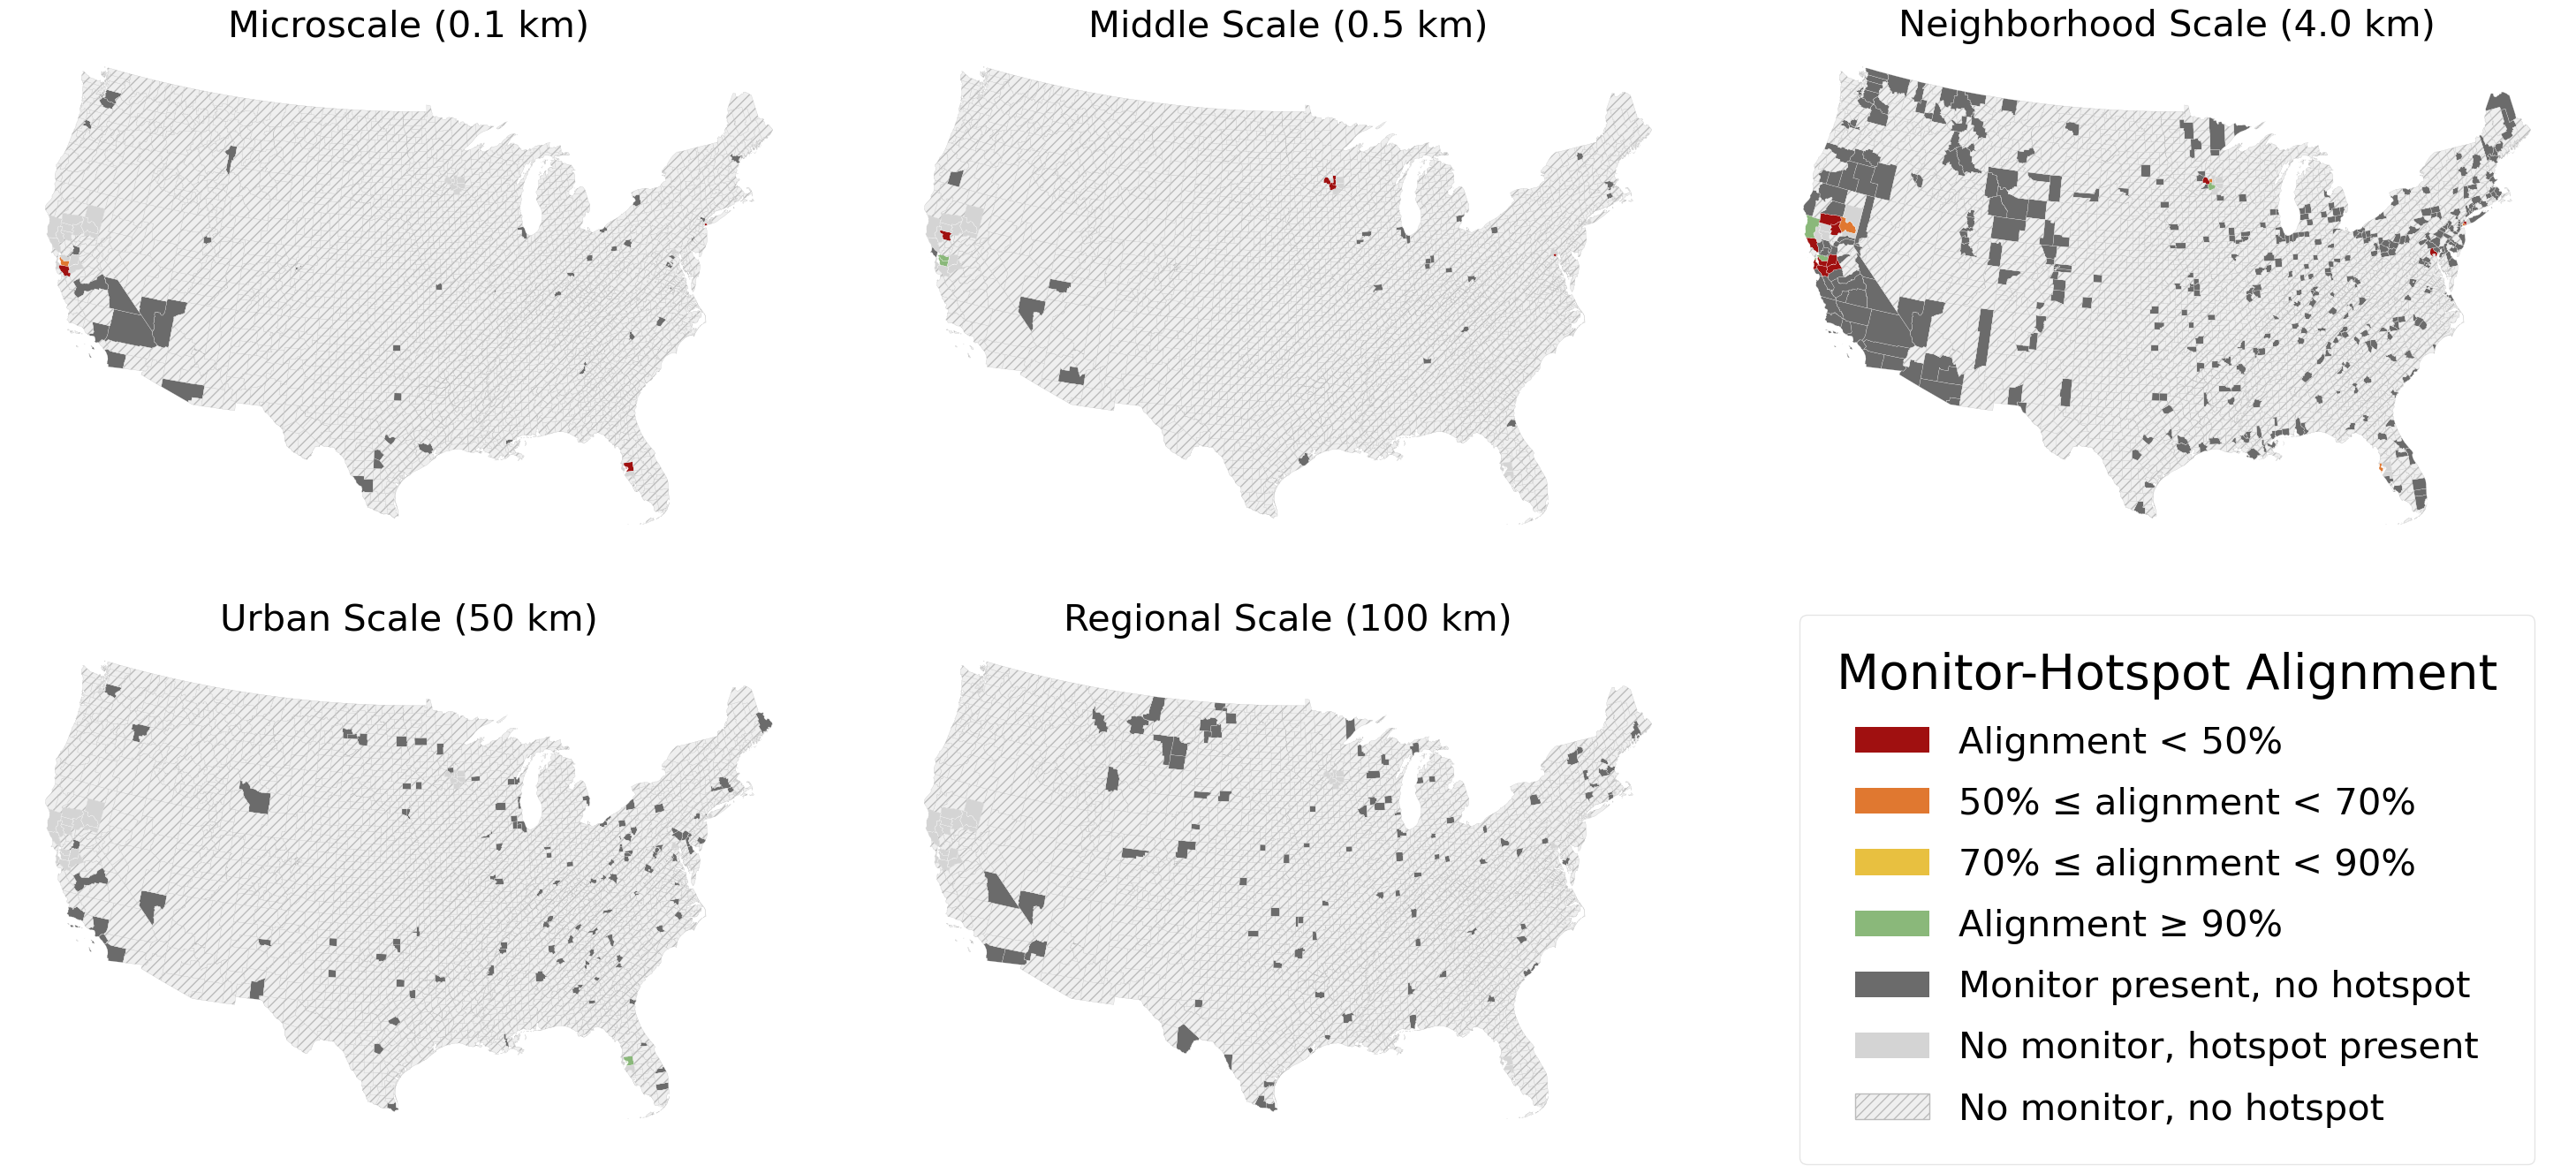

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def pct_color(row, scale, scale_monitor_geoids):
    has_monitor = row['GEOID'] in scale_monitor_geoids
    has_hotspot = row['GEOID'] in hotspot_geoids
    val         = row.get(f'alignment_{scale}')
    if has_monitor and has_hotspot:
        if pd.isna(val):   return '#A01010'
        if val < 50:       return '#A01010'
        elif val < 70:     return '#E07830'
        elif val < 90:     return '#E8C040'
        else:              return '#8AB87A'
    elif has_monitor and not has_hotspot:
        return '#6B6B6B'
    elif not has_monitor and has_hotspot:
        return '#D4D4D4'
    else:
        return '#EFEFEF'

scale_labels = {
    'MICROSCALE':     'Microscale (0.1 km)',
    'MIDDLE SCALE':   'Middle Scale (0.5 km)',
    'NEIGHBORHOOD':   'Neighborhood Scale (4.0 km)',
    'URBAN SCALE':    'Urban Scale (50 km)',
    'REGIONAL SCALE': 'Regional Scale (100 km)',
}

fig, axes = plt.subplots(2, 3, figsize=(30, 14))
axes = axes.flatten()

for i, (scale, label) in enumerate(scale_labels.items()):
    ax = axes[i]
    scale_monitor_geoids = set(monitor_county[monitor_county['Measurement_Scale'] == scale]['GEOID'].unique())
    merged = counties_conus.merge(
        county_pct[['GEOID', f'alignment_{scale}']], on='GEOID', how='left')
    merged['color'] = merged.apply(
        lambda row: pct_color(row, scale, scale_monitor_geoids), axis=1)
    merged.plot(ax=ax, color=merged['color'], edgecolor='white', linewidth=0.15)
    hatch_subset = merged[merged['color'] == '#EFEFEF']
    if not hatch_subset.empty:
        hatch_subset.plot(ax=ax, facecolor='#EFEFEF', edgecolor='#bbbbbb', hatch='///', linewidth=0.15)
    ax.set_title(label, fontsize=30)
    ax.set_axis_off()

ax_leg = axes[-1]
ax_leg.set_axis_off()
ax_leg.legend(handles=[
    Patch(facecolor='#A01010', label='Alignment < 50%'),
    Patch(facecolor='#E07830', label='50% ≤ alignment < 70%'),
    Patch(facecolor='#E8C040', label='70% ≤ alignment < 90%'),
    Patch(facecolor='#8AB87A', label='Alignment ≥ 90%'),
    Patch(facecolor='#6B6B6B', label='Monitor present, no hotspot'),
    Patch(facecolor='#D4D4D4', label='No monitor, hotspot present'),
    Patch(facecolor='#EFEFEF', hatch='///', edgecolor='#bbbbbb', label='No monitor, no hotspot'),
], title='Monitor-Hotspot Alignment', title_fontsize=40, fontsize=30,
   loc='center', framealpha=0.5, borderpad=1, labelspacing=0.7)

plt.tight_layout()
plt.savefig('alignment_map_all_scales_2021_2023.png', dpi=600, bbox_inches='tight')
plt.show()

Comparing Alignment between V6 and V5 
- Use the V5_misaligned_hotspots_0-50 
- Make another V5 misalignment dataset with a looser threshold and re-run this script with it
- Make two CONUS maps
    - Maybe use CHTC

In [28]:
# Plotting misaligned counties 

counties50 = boxesfull['county'].unique()
actual_counties = fulldf_under50['NAME'].unique()
missing = []
for c in actual_counties:
    if c not in counties50:
        missing.append(c)

print(len(missing))




NameError: name 'boxesfull' is not defined